# Exploratory Data Analysis: Telco Customer Churn

The dataset contains telecom customers and information about their demographics, services, contract types and billing.

The business goal is to predict customer churn and identify drivers of churn to support retention strategies.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/projects/telco-customer-churn

Mounted at /content/drive
/content/drive/MyDrive/projects/telco-customer-churn


## 1. Dataset overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Data types are consistent with expectations, except TotalCharges which requires conversion to numeric.

The dataset contains 7043 customer records and 18 features.

Features can be grouped into four categories:

* Demographics (gender, SeniorCitizen, Partner, Dependents)

* Services (InternetService, StreamingTV, OnlineSecurity, etc.)

* Account information (Contract, tenure, PaymentMethod)

* Financial variables (MonthlyCharges, TotalCharges)

In [4]:
df.isna().any().any()

np.False_

In [5]:
df.duplicated().sum()

np.int64(0)

## 2. Data cleaning

In [6]:
df.drop(columns=['customerID'], axis = 1, inplace = True)

In [7]:
df[df['tenure']==0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [8]:
df[df['TotalCharges'] == ' '].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

No missing values were detected, except 11 blank entries in TotalCharges.

Blank TotalCharges occur only for customers with tenure = 0, meaning they have just joined and have not been billed yet.
Replacing missing values with 0 is therefore logically consistent and avoids data leakage from imputation.

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",0)

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

In [11]:
df.to_csv('data/processed/EDA-Telco-customer-churn.csv', index = False)

In [12]:
num_cols, cat_cols = df.select_dtypes(include = ['number']).columns, df.select_dtypes(exclude = ['number']).columns

In [13]:
print(pd.DataFrame({'Categorical column': cat_cols, 'Number of categories': [df[col].nunique() for col in cat_cols]}).sort_values(by = 'Number of categories', ascending = False))

   Categorical column  Number of categories
15      PaymentMethod                     4
12    StreamingMovies                     3
8        OnlineBackup                     3
6     InternetService                     3
7      OnlineSecurity                     3
10        TechSupport                     3
11        StreamingTV                     3
9    DeviceProtection                     3
5       MultipleLines                     3
13           Contract                     3
0              gender                     2
3          Dependents                     2
4        PhoneService                     2
1       SeniorCitizen                     2
2             Partner                     2
14   PaperlessBilling                     2
16              Churn                     2


In [14]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## 3. Target analysis (Churn)

In [15]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Text(0.5, 1.0, 'Proportion of customers churn in dataset')

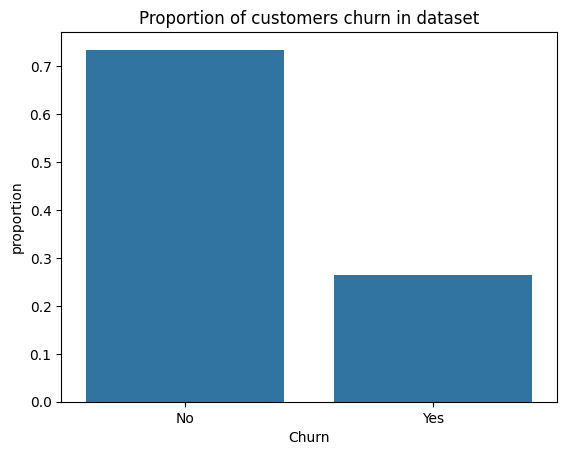

In [16]:
sns.countplot(data = df, x = 'Churn', stat = 'proportion' )
plt.title('Proportion of customers churn in dataset')


Roughly 1 in 4 customers churn.
The dataset is moderately imbalanced, which should be considered during model evaluation.

## 4. Customer demographics

To ensure consistent analysis across categorical features, I created a helper function that visualizes both class distribution and churn rate.

In [17]:
churn_rate_dict = dict() # an additional dictionary storing information about the churn rate

def churn_rate_plot(column, rotation = 0):
    churn_rate = (
        df.groupby(column)['Churn']
          .value_counts(normalize=True)
          .rename('percentage')
          .mul(100)
          .reset_index()
    )
    churn_rate_dict[column] = churn_rate
    churn_yes = churn_rate[churn_rate['Churn'] == 'Yes']

    order = df[column].value_counts().index

    fig, axs = plt.subplots(1, 2, figsize=(10,5))

    sns.countplot(x=column, data=df, hue='Churn', ax=axs[0], order = order)
    axs[0].set_title(f'Customers count by {column}')
    axs[0].set_ylabel('Count')

    sns.barplot(x=column, y='percentage', data=churn_yes, ax=axs[1], color='darkorange' , order = order, width = 0.4)
    axs[1].set_title(f'Churn rate by {column}')
    axs[1].set_ylabel('Churn rate (%)')

    for ax in axs:
        ax.tick_params(axis='x', rotation=rotation)

    plt.tight_layout()
    plt.show()

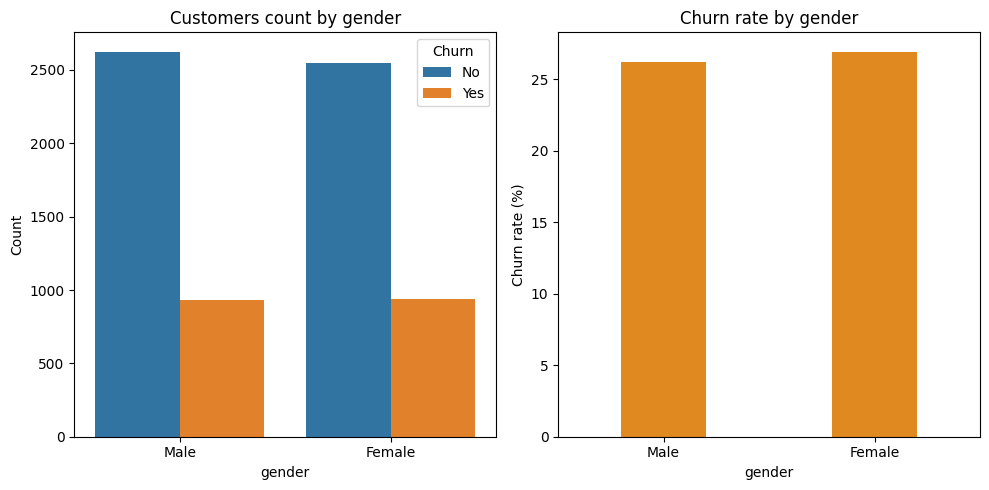

In [18]:
churn_rate_plot('gender')

No big diferences between females and males in churn.

In [19]:
df['SeniorCitizen'].value_counts(normalize=True)

,proportion
SeniorCitizen,
No,0.837853
Yes,0.162147


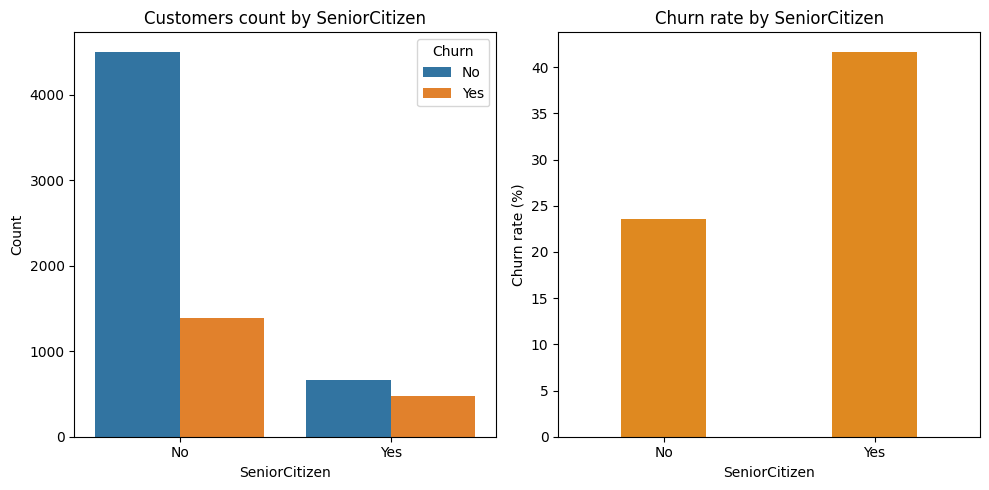

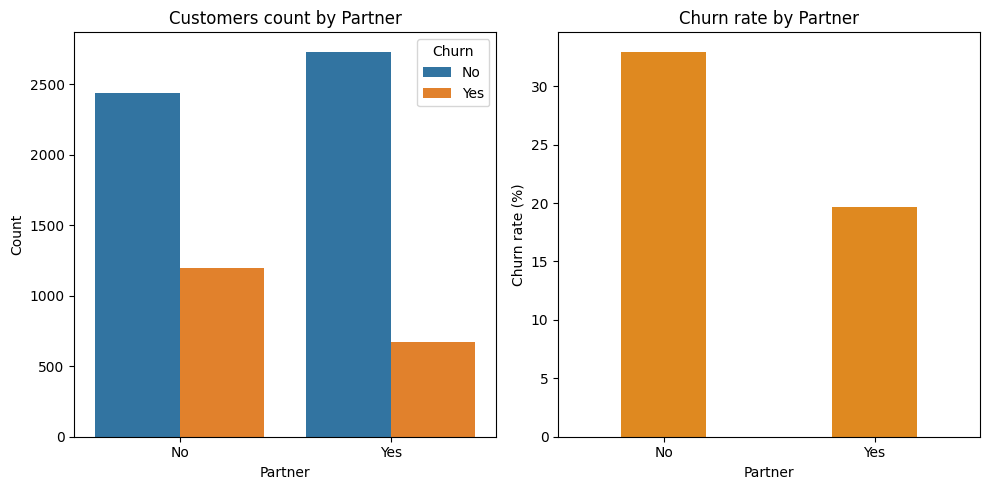

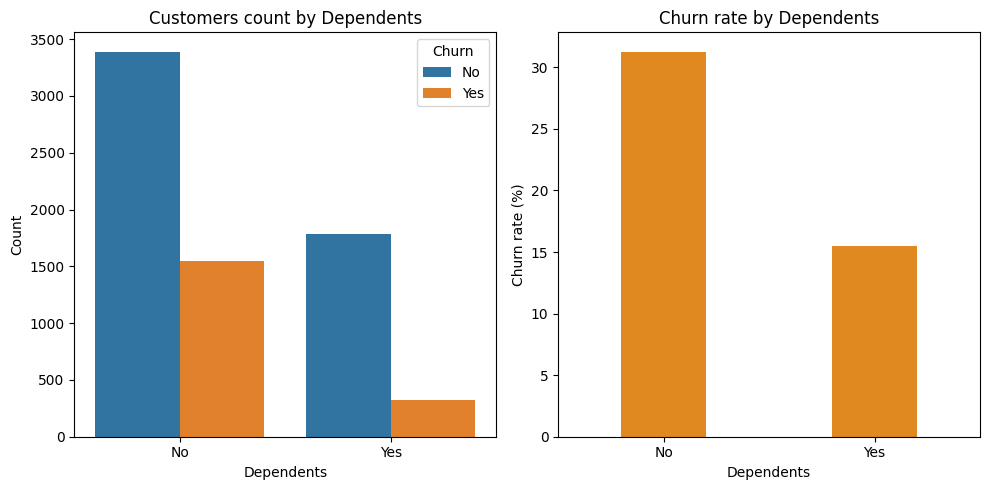

In [20]:
churn_rate_plot('SeniorCitizen')
churn_rate_plot('Partner')
churn_rate_plot('Dependents')

While demographic factors show some association with churn, their predictive strength appears weaker compared to contract and service-related features, which are analyzed in the following sections.


<Axes: xlabel='SeniorCitizen', ylabel='tenure'>

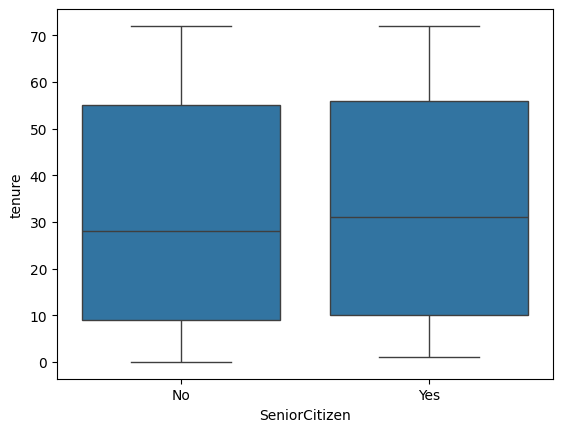

In [21]:
sns.boxplot(df, x = 'SeniorCitizen', y = 'tenure')

There is no significant difference between tenure distribiutions of Senior and other customers.

## 5. Services & behavior

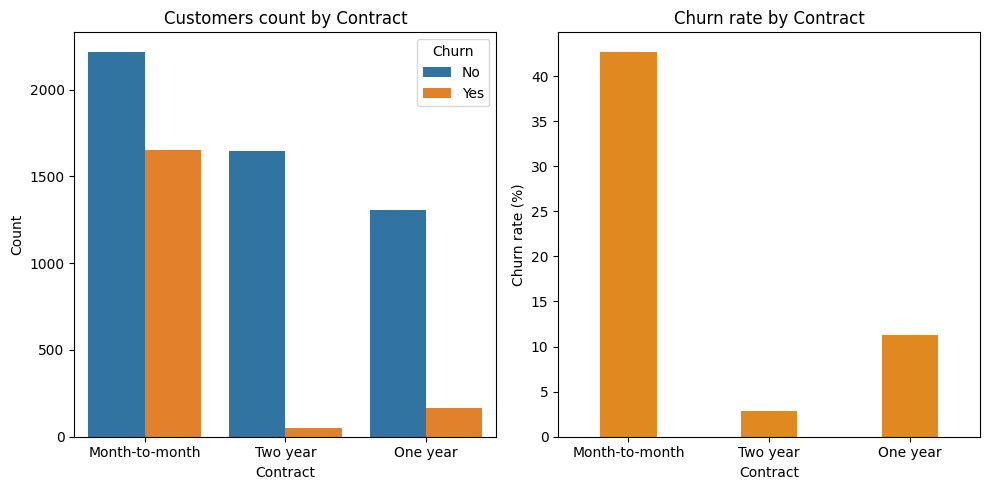

In [22]:
churn_rate_plot('Contract')

People with the Month-to-month contract show very high churn rate, while people with the two year contract almost never leave.

Text(0.5, 1.0, 'Distribution of tenure for churned vs retained customers')

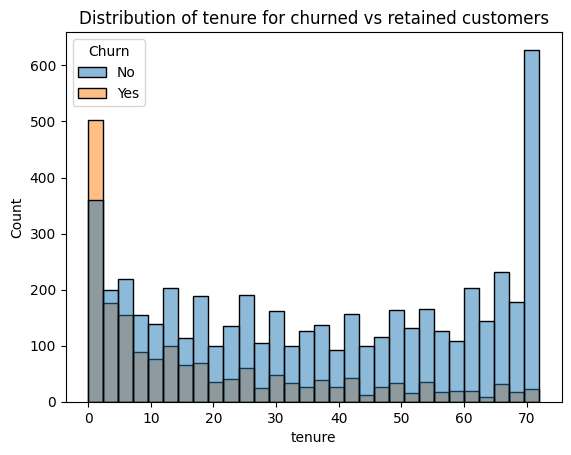

In [23]:
sns.histplot(data = df, x = 'tenure', hue = 'Churn', bins = 30)
plt.title('Distribution of tenure for churned vs retained customers')


Most churn happens early in the customer lifecycle.

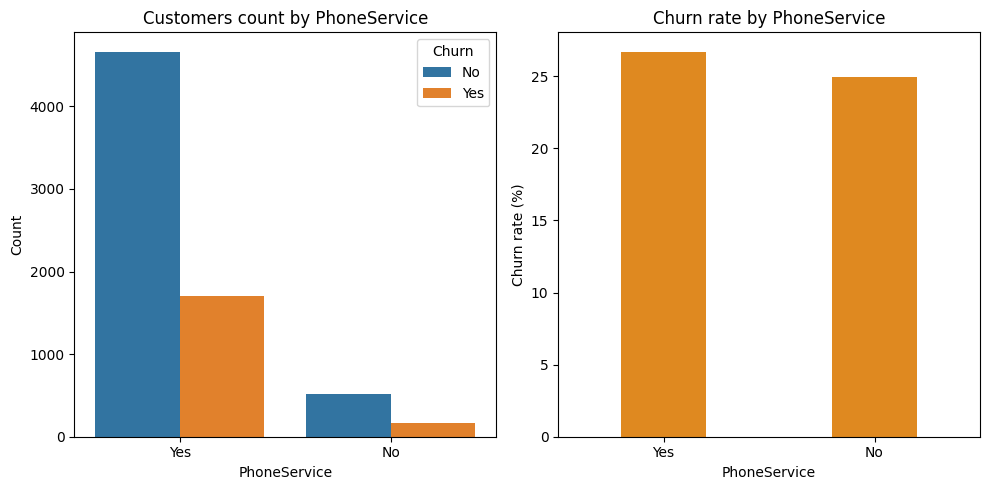

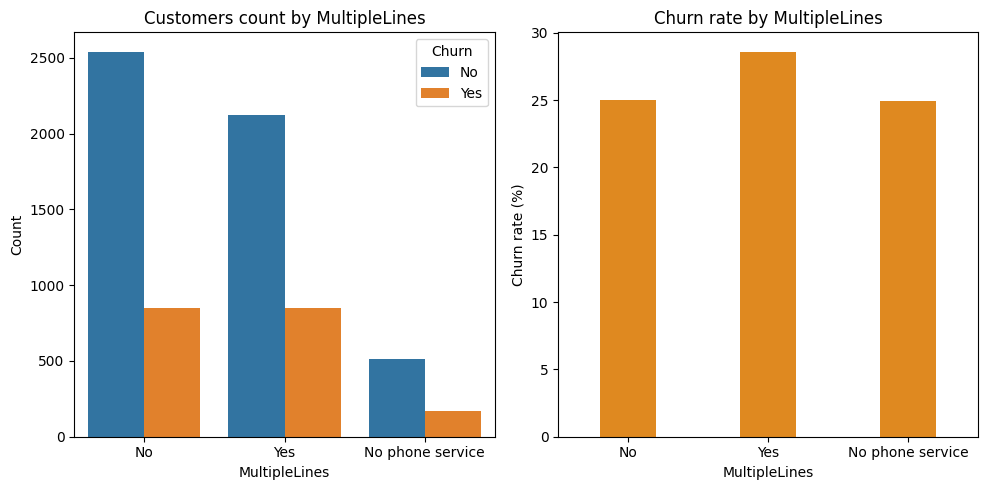

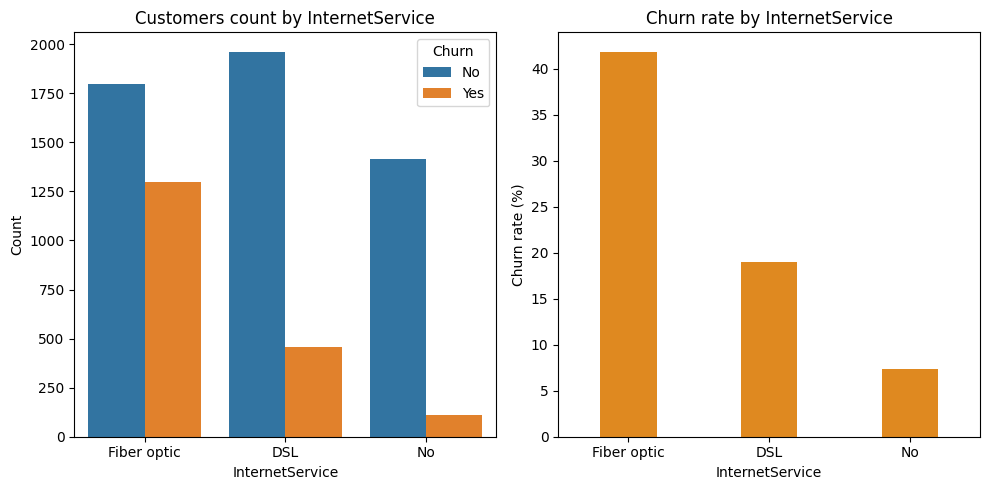

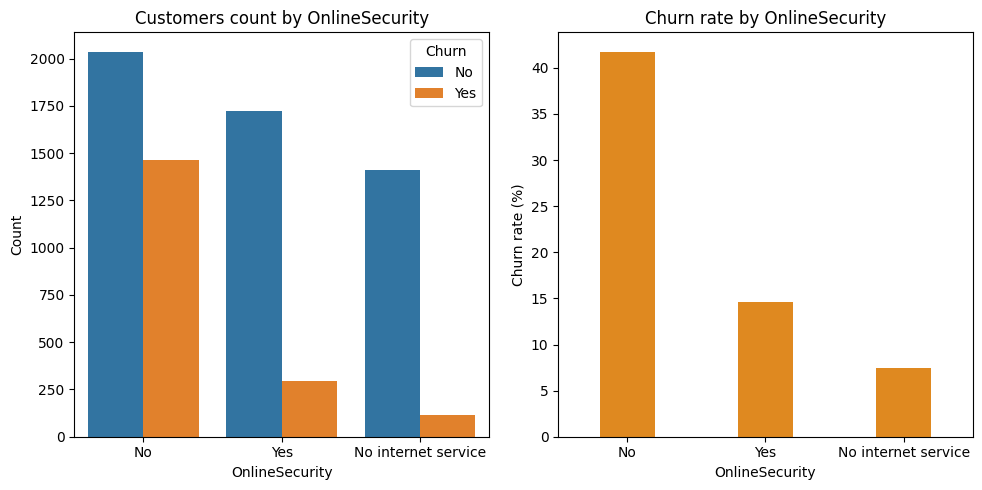

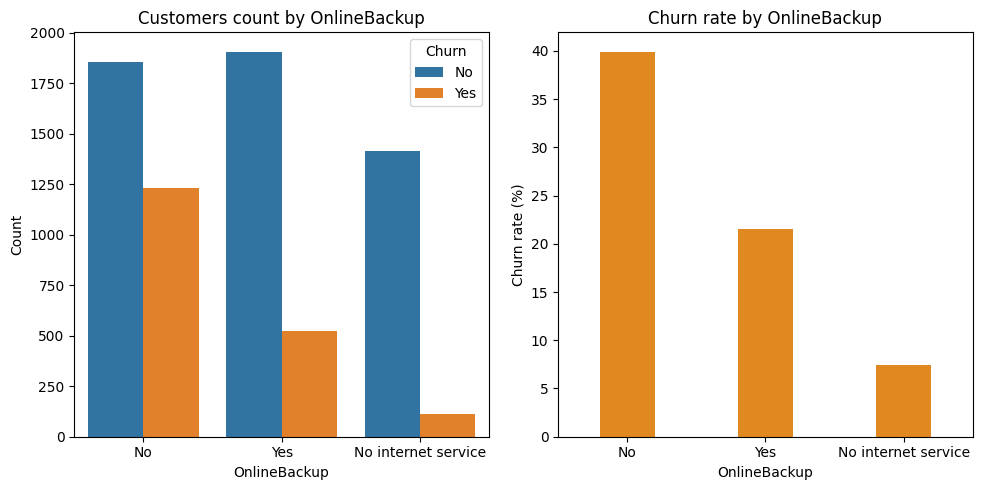

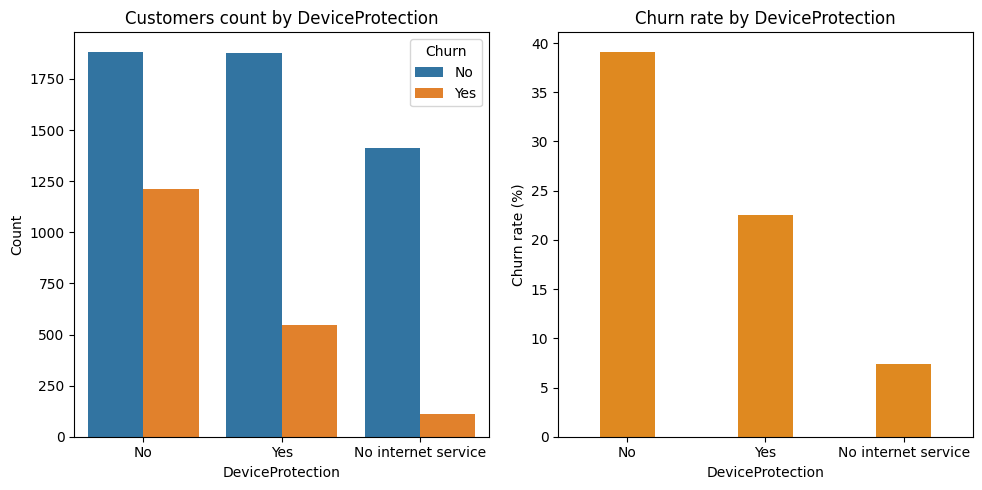

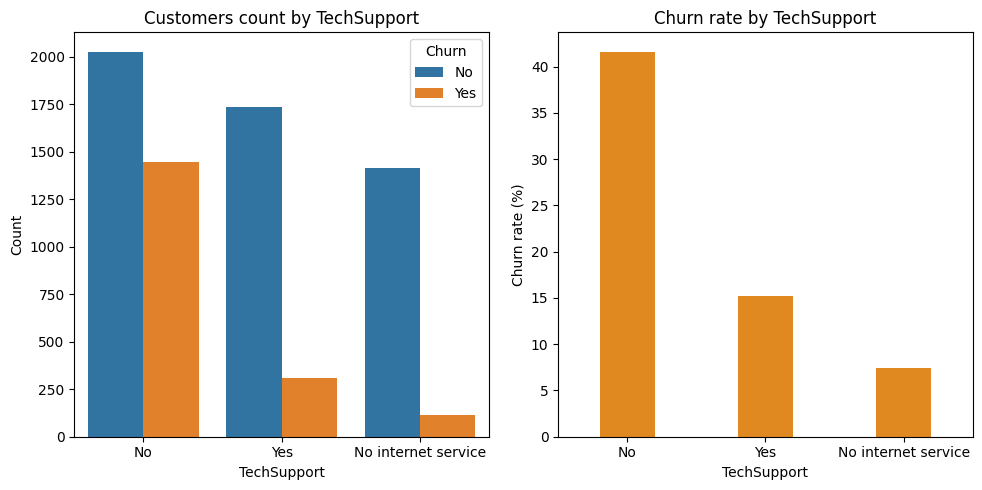

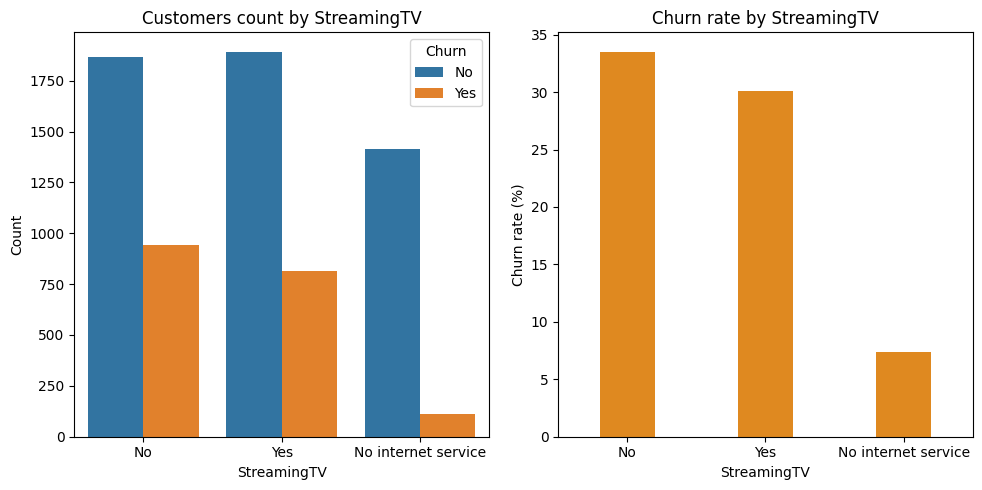

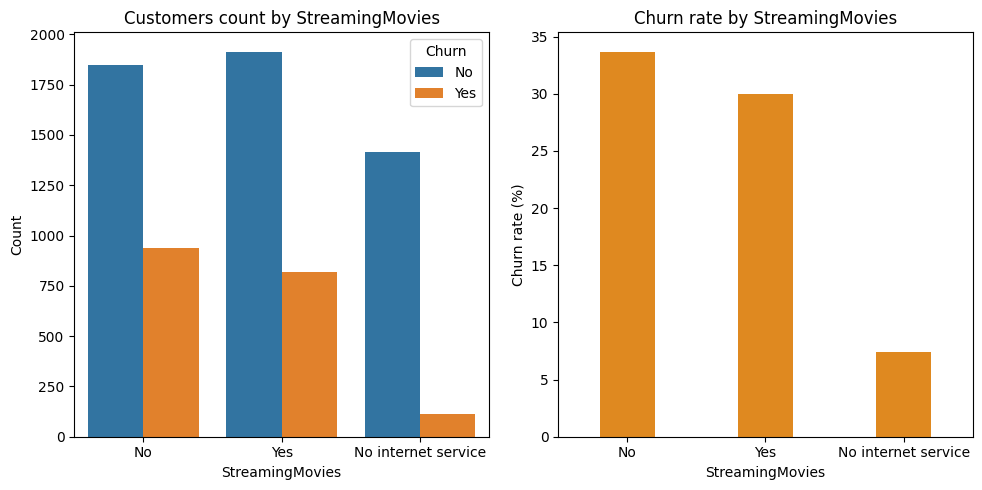

In [24]:
services = [
    'PhoneService','MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for col in services:
  churn_rate_plot(col)

Customers without additional services churn significantly more often.

This suggests that service bundling may act as a retention mechanism. Customers who invest more into the ecosystem appear more committed and less likely to switch providers.

## 6. Financial features

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

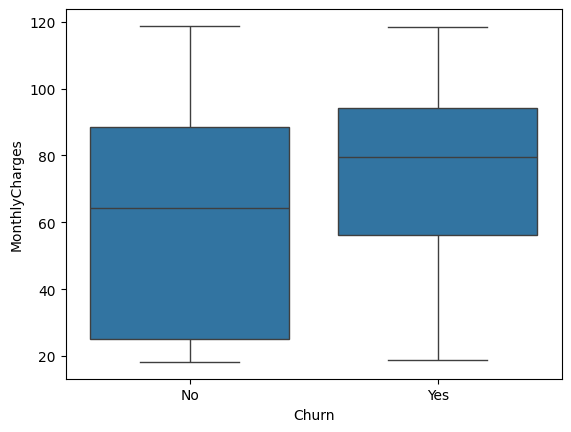

In [25]:
sns.boxplot(data = df, x = 'Churn', y = 'MonthlyCharges')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

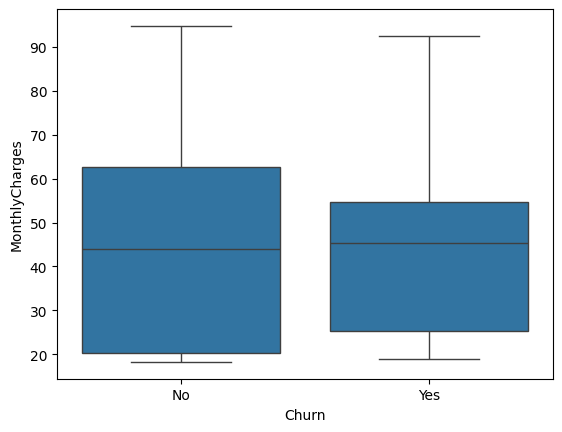

In [26]:
no_fiber_optic = df[df['InternetService']!='Fiber optic']
sns.boxplot(no_fiber_optic, x = 'Churn', y = 'MonthlyCharges')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

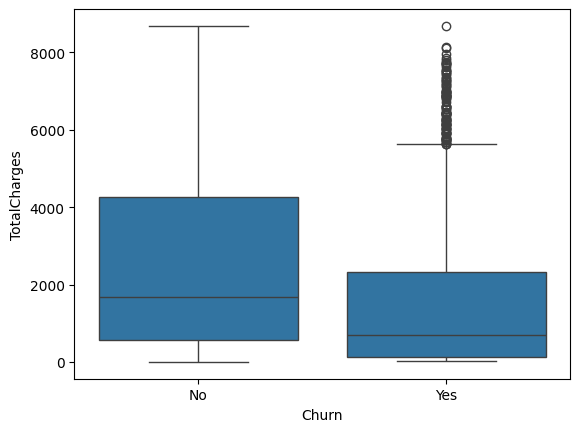

In [27]:
sns.boxplot(df, x = 'Churn', y = 'TotalCharges')

Outliers in TotalCharges are expected due to long-tenure customers and do not require removal at this stage.

Churned customers have higher monthly charges but lower total charges.
This confirms that churn is concentrated among relatively new customers paying higher monthly fees.

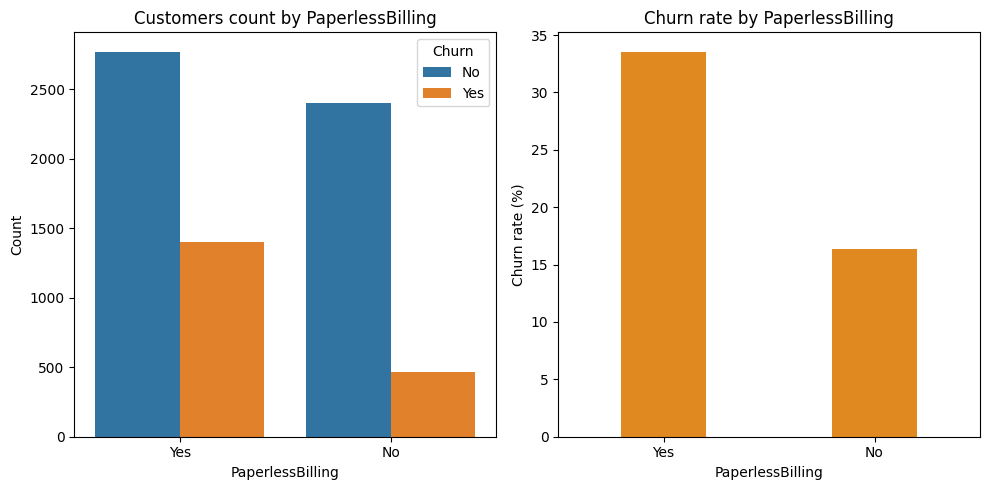

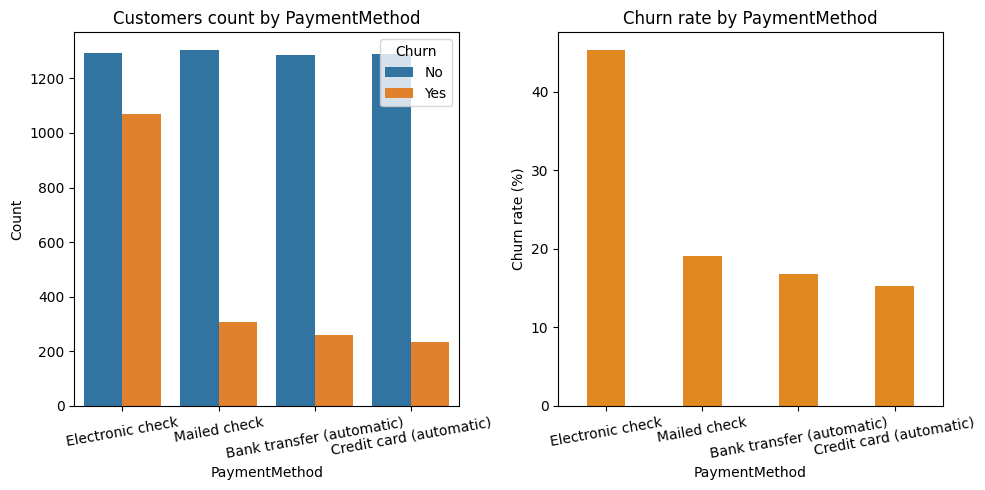

In [28]:
churn_rate_plot("PaperlessBilling")
churn_rate_plot('PaymentMethod', rotation = 10)

Customers with Paperless Billing and electronic check payment method are more likely to churn.

<Axes: >

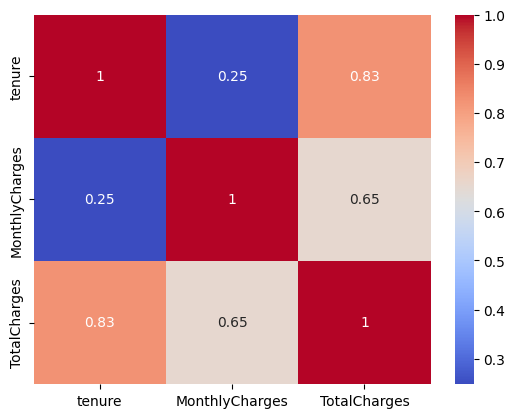

In [29]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')


As expected, TotalCharges is strongly correlated with tenure and MonthlyCharges.
No unexpected multicollinearity issues were observed.


High monthly charges combined with short tenure and flexible contracts appear to define the highest-risk churn segment.

## 7. Features sorted by churn rate

In [30]:
threshold = 35 # A threshold to distinguish higher risk of churn categories

result = []

for column_name, churn_rate_df in churn_rate_dict.items():
  tmp = (
      churn_rate_df
      .query('Churn == "Yes" and percentage > @threshold')
      .assign(Category = lambda d: column_name + ': ' + d[column_name].astype(str))
      .rename(columns = {'percentage': 'ChurnRisk'})
      [['Category','ChurnRisk']]

  )

  result.append(tmp)

churn_rate_by_categories= pd.concat(result, ignore_index = True).sort_values('ChurnRisk', ascending = False)


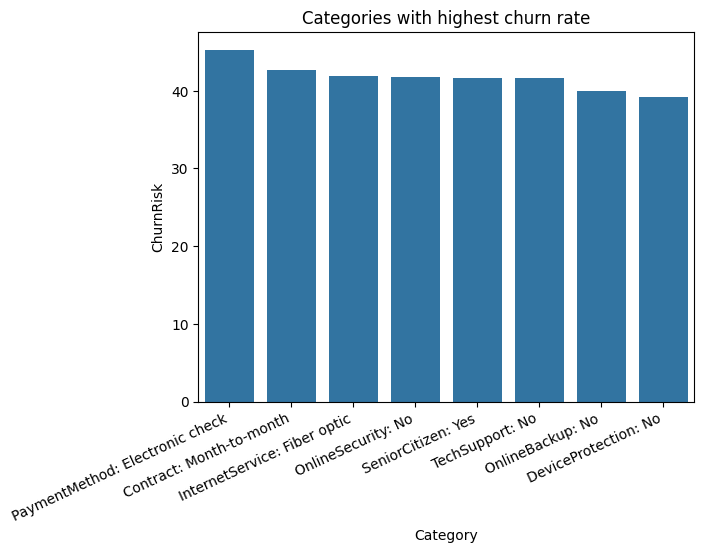

In [31]:
sns.barplot(churn_rate_by_categories, x = 'Category', y = "ChurnRisk")
plt.title("Categories with highest churn rate")
plt.xticks(rotation=25, ha='right')
plt.show()

The highest churn risk is concentrated among customers with month-to-month contracts, fiber optic internet, and non-automatic payment methods (electronic check).
Elevated churn risk is also observed among senior customers and customers without additional services.

These segments may represent priority targets for retention campaigns.


## 8. Key findings from EDA

The exploratory analysis reveals several strong churn drivers:

* Contract type is the strongest differentiator of churn.
* Churn is heavily concentrated in early tenure.
* Customers without additional services show significantly higher churn.
* Higher monthly charges are associated with increased churn risk.
* Payment behavior and billing preferences correlate with churn probability.

These findings will guide feature engineering and model development in the next stage.

## 9. Initial hypotheses

* Senior customers churn more frequently despite having a similar tenure. This may indicate higher sensitivity to service complexity, customer support quality, or usability barriers.

* Month-to-month contracts show significantly higher churn compared to long-term contracts. This may be driven by lower switching barriers and better incentives in long-term agreements.

* Most churn occurs early in the customer lifecycle, suggesting potential onboarding or early-experience issues.

* Fiber-optic customers churn more frequently, likely driven by higher monthly charges. After excluding fiber customers, the spending gap between churned and retained users narrows considerably.
* Customers with more subscribed services are less likely to churn.

* Lack of security and technical support services increases churn risk.

* Customers with paperless billing are more likely to churn. This may indicate that digitally engaged customers are more willing to switch providers and compare alternative offers.

* Customers using automatic payment methods (credit card or bank transfer) are expected to have lower churn rates compared to customers using manual payment methods.
